In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "C:/Users/dimit/Desktop/new/Mamoth Modules")

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
def process_greek(dataframe, column):
    dataframe[column] = dataframe[column].apply(lambda x : x.strip())
    dataframe[column] = dataframe[column].apply(lambda x : x.lower())
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ά','α'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('έ','ε'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ή','η'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ί','ι'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ύ','υ'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ό','ο'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ώ','ω'))

def fillna(dataframe,fill_list):
    for i in list(fill_list.keys()):
        if i not in dataframe.columns:
            raise KeyError('Column(s) not in index')
        else:
            dataframe[i] = dataframe[i].fillna(fill_list[i])
    return dataframe

def describe_dataframe(dataframe):
    df_desc = pd.DataFrame(columns=['Column', 'Missing'])

    for col in dataframe.columns:
        df_desc = df_desc.append({'Column': col, 
                                'Missing': (dataframe[col].isnull().sum() * 100 / len(dataframe[col]))}, ignore_index = True)
    
    return df_desc

def lau1_mapping(dataframe, x0, y0, lau1_col = 'lau1', map_col = 'lau1_id', dist_col = 'eq_distance'):
    data = dataframe
    data[dist_col] = data.apply(lambda row : round(math.sqrt(math.pow((row['x']-x0) , 2) + math.pow((row['y']-y0) , 2)),5), axis = 1)
    data_sub = data[[lau1_col, dist_col]]
    data_sorted = data_sub.sort_values(dist_col).drop_duplicates(ignore_index = True)
    data_sorted[map_col] = data_sorted.index
    
    mapping = {}
    for index, row in data_sorted.iterrows():
        mapping[row[lau1_col]] = row[map_col]
        
    return mapping

def encode_cyclical(dataframe, col, max_val):
    dataframe[col + '_sin'] = np.sin(2 * np.pi * dataframe[col]/max_val)
    dataframe[col + '_cos'] = np.cos(2 * np.pi * dataframe[col]/max_val)

    return dataframe

def dataset_mamoth_preparation(dataframe, columns, del_months = None, month_col = 'month'):

    dataset_mamoth = dataframe.copy()
    dataset_mamoth['lst_jan_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_jan_day_mean'],row['lst_jan_night_mean']]), axis=1)
    dataset_mamoth['lst_feb_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_feb_day_mean'],row['lst_feb_night_mean']]), axis=1)
    dataset_mamoth['lst_mar_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_mar_day_mean'],row['lst_mar_night_mean']]), axis=1)
    dataset_mamoth['lst_apr_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_apr_day_mean'],row['lst_apr_night_mean']]), axis=1)
    dataset_mamoth['mosq_now'] = 0

    if del_months != None:
        dataset_mamoth = dataset_mamoth[~dataset_mamoth[month_col].isin(del_months)]

    dataset_mamoth = dataset_mamoth[columns]

    dataset_mamoth.reset_index(inplace=True, drop=True)

    return dataset_mamoth

def calculate_mosq_previous(dataframe, lau1_col = 'lau1', date_col = 'dt_placement', mosq_prediction_col = 'mosq_pred', result_col = 'mosq_previous'):

    for municipality in dataframe[lau1_col].drop_duplicates():

        data = dataframe.loc[dataframe[lau1_col] == municipality].copy()
        data.sort_values(by=[date_col], inplace = True)
        data.reset_index(inplace = True, drop = True)
        
        for index, row in data.iterrows():
        
            try:
                mosq_minus_2 = data.loc[index-2, mosq_prediction_col]
            except KeyError:
                mosq_minus_2 = 0
        
            try:
                mosq_minus_1 = data.loc[index-1, mosq_prediction_col]
            except KeyError:
                mosq_minus_1 = 0
            
            mosq_sum = mosq_minus_2 + mosq_minus_1
        
            index_at_dataframe = dataframe.index[(dataframe[lau1_col] == row[lau1_col]) & (dataframe[date_col] == row[date_col])].tolist()
            if (len(index_at_dataframe) != 1):
                raise(IndexError("Duplicate Index Found"))
            
            dataframe.at[index_at_dataframe[0], result_col] = mosq_sum

    return dataframe

def convert_temperature(dataframe, result_col = 'lst'):
    temprature_cols = dataframe.filter(regex='^lst_*').columns.tolist()

    dataframe[temprature_cols] = dataframe[temprature_cols].apply(lambda x : x * 0.02 - 273.15)
    dataframe[result_col] = (dataframe['lst_day'] + dataframe['lst_night'])/2

    return dataframe

def convert_multiple_cases(dataframe, target_col = 'case'):

    case_counts = dataframe[target_col].value_counts().index

    for case_count in case_counts:
        if (case_count >= 2):
            dataframe = dataframe.append([dataframe[dataframe[target_col] == case_count]] * (case_count - 1), ignore_index=True)
            
    dataframe[target_col] = dataframe['case'].apply(lambda x : 1 if(x > 0) else 0)

    return dataframe


In [3]:
thessaly_shp = pd.read_csv('data/GR_Thessaly_Spatiotemporal_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
thessaly_wnv = pd.read_csv('data/GR_Thessaly_Epidemiological_Timeline_2010-2021.csv', encoding=enc)

In [4]:
thessaly_shp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36288 entries, 0 to 36287
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipality            36288 non-null  object 
 1   region                  36288 non-null  object 
 2   x                       36288 non-null  float64
 3   y                       36288 non-null  float64
 4   dt_placement            36288 non-null  object 
 5   year                    36288 non-null  int64  
 6   month                   36288 non-null  int64  
 7   indices_image_date      36288 non-null  object 
 8   indices_lat             36288 non-null  float64
 9   indices_lon             36288 non-null  float64
 10  ndvi_new                31995 non-null  float64
 11  ndmi_new                31995 non-null  float64
 12  ndwi_new                31995 non-null  float64
 13  ndbi_new                31995 non-null  float64
 14  ndvi_mean_new           32538 non-null

In [5]:
thessaly_wnv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   lau1          1800 non-null   object
 1   nuts2         1800 non-null   object
 2   dt_placement  1800 non-null   object
 3   case          1800 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 56.4+ KB


In [6]:
process_greek(thessaly_shp, 'municipality')
process_greek(thessaly_shp, 'region')

In [7]:
thessaly_shp.rename(columns={"municipality": "lau1", "region": "nuts2"}, inplace=True)

In [8]:
thessaly_shp['nuts2'] = 'θεσσαλιας'

In [9]:
thessaly_shp = thessaly_shp.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
thessaly_shp.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon', 'idy','idx','monthly_lst_lat','monthly_lst_lon'], inplace = True)

In [11]:
thessaly_shp.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,αγιας,θεσσαλιας,22.70702,39.62884,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14469.0,NaN,14191.363636,13933.714286,14259.000000,13850.833333,14612.642857,13982.705882,14825.846154,14077.466667,323,323,323,323,323,22.3,58.1,NaN
1,αγιας,θεσσαλιας,22.70702,39.62884,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.0,13842.0,14191.363636,13933.714286,14259.000000,13850.833333,14612.642857,13982.705882,14825.846154,14077.466667,323,323,323,323,323,12.0,14.1,14.1
2,αγιας,θεσσαλιας,22.75360,39.64680,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14487.0,NaN,14121.818182,13942.500000,14172.333333,13869.500000,14514.500000,14000.176471,14643.875000,14082.533333,243,243,243,243,243,22.3,58.1,NaN
3,αγιας,θεσσαλιας,22.75360,39.64680,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.0,13915.0,14121.818182,13942.500000,14172.333333,13869.500000,14514.500000,14000.176471,14643.875000,14082.533333,243,243,243,243,243,12.0,14.1,14.1
4,αγιας,θεσσαλιας,22.75360,39.73664,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14518.0,NaN,14330.000000,13872.250000,14152.375000,13893.900000,14536.428571,13953.588235,14647.500000,14043.000000,243,243,243,243,243,19.7,43.4,NaN


In [12]:
thessaly_wnv.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [13]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

list1 = thessaly_wnv["lau1"].drop_duplicates().sort_values().tolist()
list2 = thessaly_shp["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")


['ρηγα φεραιου']

Length: 1


In [14]:
thessaly_shp['lau1'] = thessaly_shp['lau1'].apply(lambda x : x.replace('ρηγα φερραιου','ρηγα φεραιου'))

In [15]:
## Check again

list1 = thessaly_wnv["lau1"].drop_duplicates().sort_values().tolist()
list2 = thessaly_shp["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [16]:
merged = thessaly_shp.merge(thessaly_wnv, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [17]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,αγιας,θεσσαλιας,22.70702,39.62884,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14469.0,NaN,14191.363636,13933.714286,14259.000000,13850.833333,14612.642857,13982.705882,14825.846154,14077.466667,323,323,323,323,323,22.3,58.1,NaN,NaN
1,αγιας,θεσσαλιας,22.70702,39.62884,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.0,13842.0,14191.363636,13933.714286,14259.000000,13850.833333,14612.642857,13982.705882,14825.846154,14077.466667,323,323,323,323,323,12.0,14.1,14.1,NaN
2,αγιας,θεσσαλιας,22.75360,39.64680,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14487.0,NaN,14121.818182,13942.500000,14172.333333,13869.500000,14514.500000,14000.176471,14643.875000,14082.533333,243,243,243,243,243,22.3,58.1,NaN,NaN
3,αγιας,θεσσαλιας,22.75360,39.64680,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.0,13915.0,14121.818182,13942.500000,14172.333333,13869.500000,14514.500000,14000.176471,14643.875000,14082.533333,243,243,243,243,243,12.0,14.1,14.1,NaN
4,αγιας,θεσσαλιας,22.75360,39.73664,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14518.0,NaN,14330.000000,13872.250000,14152.375000,13893.900000,14536.428571,13953.588235,14647.500000,14043.000000,243,243,243,243,243,19.7,43.4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36283,φαρσαλων,θεσσαλιας,22.47914,39.26510,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14169.076923,13695.000000,14430.000000,13882.125000,14521.058824,13810.461538,14845.230769,14031.117647,211,211,211,211,211,NaN,NaN,829.4,NaN
36284,φαρσαλων,θεσσαλιας,22.57178,39.28306,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14047.066667,13727.428571,14375.562500,13926.529412,14452.000000,13847.062500,14812.857143,14046.733333,323,323,323,323,323,105.6,135.9,752.6,NaN
36285,φαρσαλων,θεσσαλιας,22.57178,39.28306,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14047.066667,13727.428571,14375.562500,13926.529412,14452.000000,13847.062500,14812.857143,14046.733333,323,323,323,323,323,NaN,NaN,752.6,NaN
36286,φαρσαλων,θεσσαλιας,22.59495,39.31900,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14116.769231,13619.000000,14502.466667,13858.733333,14601.000000,13757.666667,14872.642857,13961.352941,211,211,211,211,211,79.1,112.5,838.9,NaN


In [18]:
merged = fillna(merged,{'case': 0, 'acc_rainfall_1week':0, 'acc_rainfall_2week':0, 'acc_rainfall_jan':0})

In [19]:
merged['case'].value_counts()

0.0    35872
1.0      233
2.0      147
3.0       34
7.0        2
Name: case, dtype: int64

In [20]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [21]:
dataset = grouped.mean()

In [22]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,2010-01-01,αγιας,θεσσαλιας,22.773559,39.677604,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14471.714286,14070.0,14219.612013,13922.623469,14136.897294,13878.458472,14496.295766,13962.024806,14633.668886,14065.292672,295.000000,295.000000,295.000000,295.000000,295.000000,22.057143,52.814286,0.000000,0.0
1,2010-01-01,αλμυρου,θεσσαλιας,22.694933,39.108442,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.222222,14253.0,14152.345459,13870.776279,14191.387279,13838.430904,14509.453398,13940.006808,14684.551160,14038.175999,260.444444,260.444444,260.444444,260.444444,260.444444,13.700000,31.211111,0.300000,0.0
2,2010-01-01,αλοννησου,θεσσαλιας,23.911890,39.203200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14531.000000,14248.0,14291.857143,14136.142857,14248.230769,14025.000000,14403.076923,14089.200000,14549.130435,14178.875000,323.000000,323.000000,323.000000,323.000000,323.000000,62.200000,98.600000,0.000000,0.0
3,2010-01-01,αργιθεας,θεσσαλιας,21.430517,39.257313,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13579.222222,13686.888889,13946.166667,13586.089947,14322.111111,13797.862238,14594.027715,13969.056548,323.666667,323.666667,320.000000,320.000000,320.000000,47.133333,88.466667,22.100000,0.0
4,2010-01-01,βολου,θεσσαλιας,22.937920,39.411863,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14525.333333,NaN,14299.755952,13912.791667,14261.975758,13850.627350,14527.885470,13975.904412,14742.691667,14097.754579,252.666667,252.666667,252.666667,252.666667,252.666667,30.066667,48.733333,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.539156,39.855704,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13908.747912,13643.002143,14205.595357,13867.065735,14298.427381,13761.768022,14603.587262,13897.571190,301.000000,301.000000,296.200000,296.200000,296.200000,0.000000,0.000000,788.880000,0.0
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.816174,39.631464,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14155.953333,13736.146667,14361.958303,13873.382129,14577.722500,13796.656244,14873.710334,13993.580556,255.600000,255.600000,235.800000,235.800000,235.800000,0.000000,0.000000,819.310000,0.0
7197,2021-12-16,τυρναβου,θεσσαλιας,22.296360,39.788050,2021.0,12.0,0.388837,0.187181,-0.28902,-0.187181,0.440473,0.204898,-0.322835,-0.204898,0.056187,0.062905,0.077934,0.062905,NaN,NaN,14132.917582,13744.295202,14343.024483,13911.197325,14538.729365,13869.083791,14796.202381,14027.050919,294.750000,294.750000,294.750000,294.750000,294.750000,0.000000,0.000000,758.962500,0.0
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.051600,39.609733,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14172.071429,13735.661111,14399.642857,13923.259259,14576.440171,13877.647817,14877.902625,14076.595861,321.000000,321.000000,321.000000,322.000000,322.000000,0.000000,0.000000,737.533333,0.0


In [23]:
dataset = dataset.astype({'case': 'int'})

In [24]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [26]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [27]:
with open('data/GR_WNV_Thessaly_LAU1_mapping.json', 'w', encoding=enc) as file:
     json.dump(lau1_map,file,sort_keys=True, indent=4, ensure_ascii=False)

In [28]:
dataset["lau1_id"] = dataset["lau1"].map(lau1_map)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αγιας,θεσσαλιας,22.77356,39.67760,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14471.714286,14070.0,14219.612013,13922.623469,14136.897294,13878.458472,14496.295766,13962.024806,14633.668886,14065.292672,295.000000,295.000000,295.000000,295.000000,295.000000,22.057143,52.814286,0.000000,0,1,53,45.74874,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλμυρου,θεσσαλιας,22.69493,39.10844,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.222222,14253.0,14152.345459,13870.776279,14191.387279,13838.430904,14509.453398,13940.006808,14684.551160,14038.175999,260.444444,260.444444,260.444444,260.444444,260.444444,13.700000,31.211111,0.300000,0,1,53,45.21648,6,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αλοννησου,θεσσαλιας,23.91189,39.20320,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14531.000000,14248.0,14291.857143,14136.142857,14248.230769,14025.000000,14403.076923,14089.200000,14549.130435,14178.875000,323.000000,323.000000,323.000000,323.000000,323.000000,62.200000,98.600000,0.000000,0,1,53,45.92025,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αργιθεας,θεσσαλιας,21.43052,39.25731,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13579.222222,13686.888889,13946.166667,13586.089947,14322.111111,13797.862238,14594.027715,13969.056548,323.666667,323.666667,320.000000,320.000000,320.000000,47.133333,88.466667,22.100000,0,1,53,44.72587,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,βολου,θεσσαλιας,22.93792,39.41186,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14525.333333,NaN,14299.755952,13912.791667,14261.975758,13850.627350,14527.885470,13975.904412,14742.691667,14097.754579,252.666667,252.666667,252.666667,252.666667,252.666667,30.066667,48.733333,0.000000,0,1,53,45.60091,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.53916,39.85570,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13908.747912,13643.002143,14205.595357,13867.065735,14298.427381,13761.768022,14603.587262,13897.571190,301.000000,301.000000,296.200000,296.200000,296.200000,0.000000,0.000000,788.880000,0,16,50,45.78745,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.81617,39.63146,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14155.953333,13736.146667,14361.958303,13873.382129,14577.722500,13796.656244,14873.710334,13993.580556,255.600000,255.600000,235.800000,235.800000,235.800000,0.000000,0.000000,819.310000,0,16,50,45.23934,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7197,2021-12-16,τυρναβου,θεσσαλιας,22.29636,39.78805,2021,12,0.388837,0.187181,-0.28902,-0.187181,0.440473,0.204898,-0.322835,-0.204898,0.056187,0.062905,0.077934,0.062905,NaN,NaN,14132.917582,13744.295202,14343.024483,13911.197325,14538.729365,13869.083791,14796.202381,14027.050919,294.750000,294.750000,294.750000,294.750000,294.750000,0.000000,0.000000,758.962500,0,16,50,45.60939,15,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.05160,39.60973,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

<AxesSubplot:>

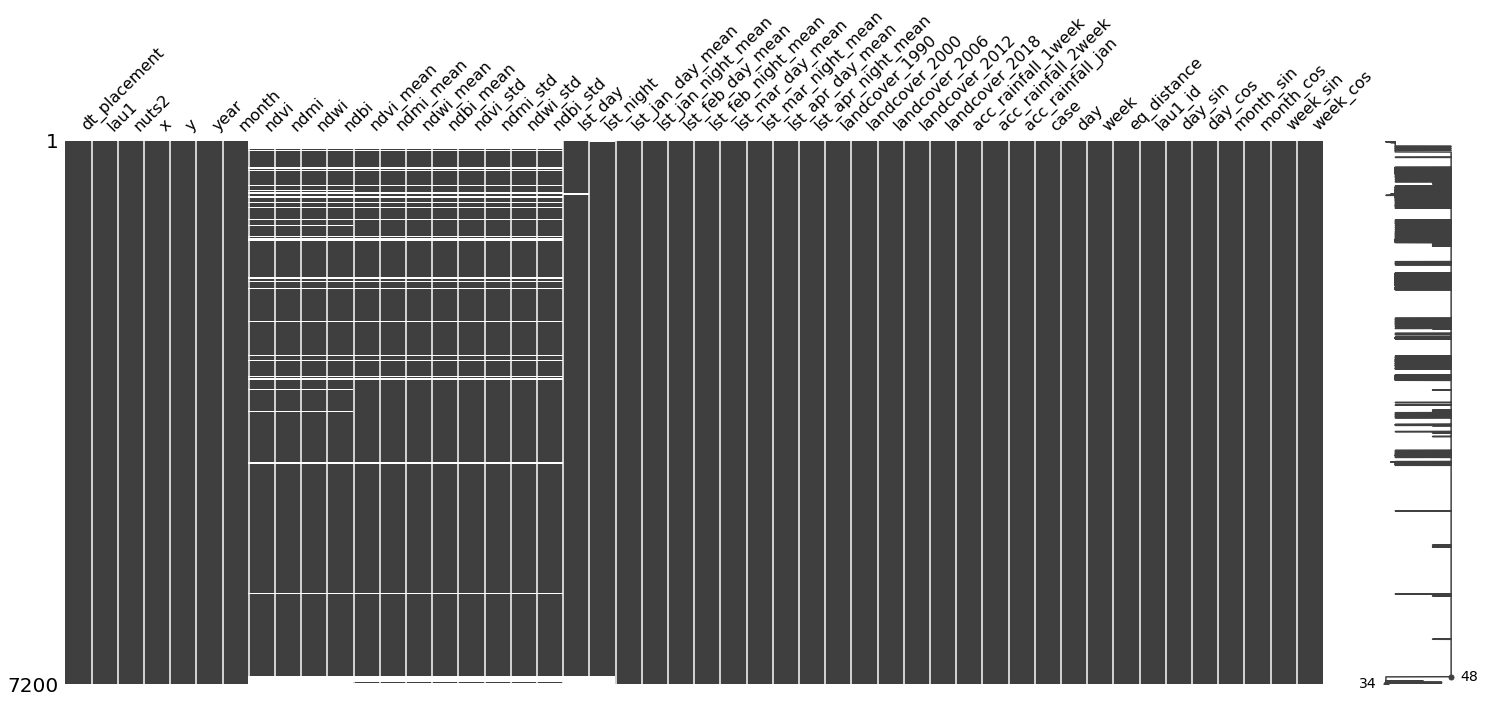

In [30]:
missingno.matrix(dataset)

In [31]:
df_demographics = pd.read_csv('data/GR_WEB_Demographics_Processed.csv', encoding = enc)

In [32]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [33]:
df_demographics_thessaly = df_demographics.query("nuts2 == 'θεσσαλιας'").copy()

In [34]:
df_demographics_thessaly.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_thessaly.reset_index(inplace=True, drop=True)

In [35]:
df_demographics_thessaly

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [36]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_thessaly["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

['ζαγορας - μουρεσιου', 'καλαμπακας', 'λαρισαιων', 'φαρκαδονας']

Length: 4


In [37]:
df_demographics_thessaly['lau1'] = df_demographics_thessaly['lau1'].apply(lambda x : x.replace('ζαγορας-μουρεσιου','ζαγορας - μουρεσιου'))
df_demographics_thessaly['lau1'] = df_demographics_thessaly['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_thessaly['lau1'] = df_demographics_thessaly['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_thessaly['lau1'] = df_demographics_thessaly['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [38]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_thessaly["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [39]:
dataset = pd.merge(dataset, df_demographics_thessaly,  how='left', on=['lau1'])

<AxesSubplot:>

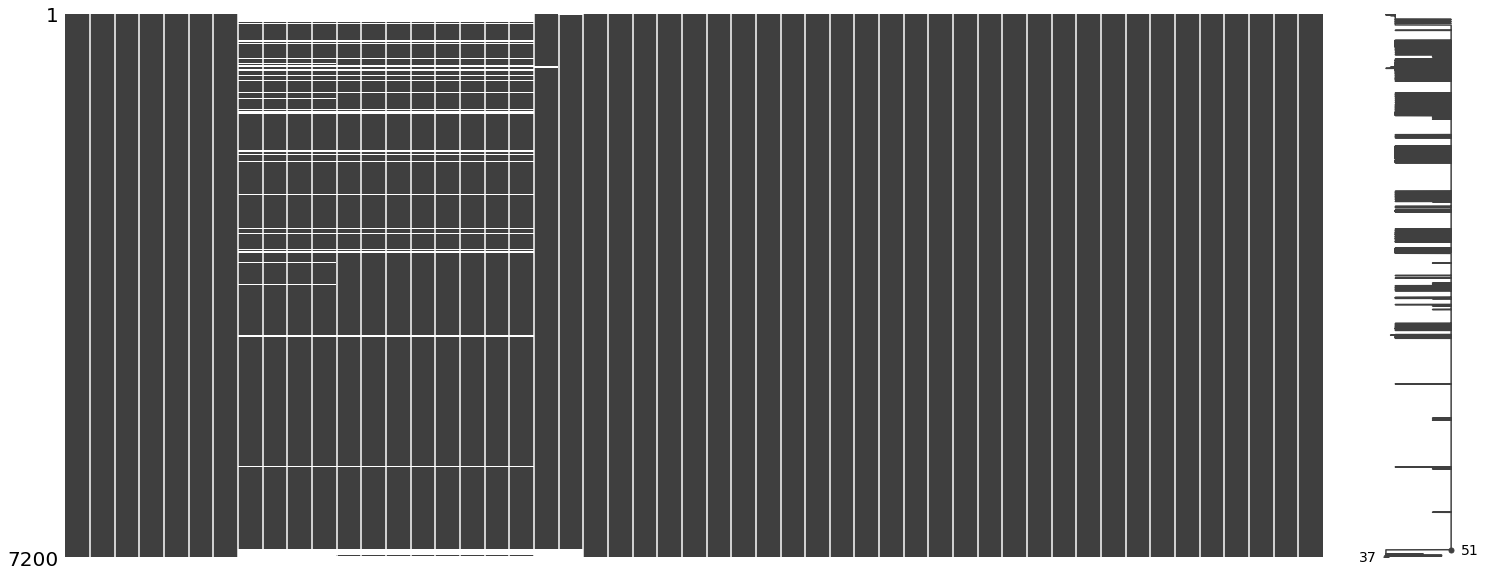

In [40]:
missingno.matrix(dataset)

In [41]:
missing = describe_dataframe(dataset)

In [42]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αγιας,θεσσαλιας,22.77356,39.67760,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14471.714286,14070.0,14219.612013,13922.623469,14136.897294,13878.458472,14496.295766,13962.024806,14633.668886,14065.292672,295.000000,295.000000,295.000000,295.000000,295.000000,22.057143,52.814286,0.000000,0,1,53,45.74874,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,661.8,17.3,10705.00
1,2010-01-01,αλμυρου,θεσσαλιας,22.69493,39.10844,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.222222,14253.0,14152.345459,13870.776279,14191.387279,13838.430904,14509.453398,13940.006808,14684.551160,14038.175999,260.444444,260.444444,260.444444,260.444444,260.444444,13.700000,31.211111,0.300000,0,1,53,45.21648,6,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,905.4,20.6,16004.00
2,2010-01-01,αλοννησου,θεσσαλιας,23.91189,39.20320,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14531.000000,14248.0,14291.857143,14136.142857,14248.230769,14025.000000,14403.076923,14089.200000,14549.130435,14178.875000,323.000000,323.000000,323.000000,323.000000,323.000000,62.200000,98.600000,0.000000,0,1,53,45.92025,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,129.6,21.2,3153.00
3,2010-01-01,αργιθεας,θεσσαλιας,21.43052,39.25731,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13579.222222,13686.888889,13946.166667,13586.089947,14322.111111,13797.862238,14594.027715,13969.056548,323.666667,323.666667,320.000000,320.000000,320.000000,47.133333,88.466667,22.100000,0,1,53,44.72587,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,372.9,9.3,3515.00
4,2010-01-01,βολου,θεσσαλιας,22.93792,39.41186,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14525.333333,NaN,14299.755952,13912.791667,14261.975758,13850.627350,14527.885470,13975.904412,14742.691667,14097.754579,252.666667,252.666667,252.666667,252.666667,252.666667,30.066667,48.733333,0.000000,0,1,53,45.60091,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.53916,39.85570,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13908.747912,13643.002143,14205.595357,13867.065735,14298.427381,13761.768022,14603.587262,13897.571190,301.000000,301.000000,296.200000,296.200000,296.200000,0.000000,0.000000,788.880000,0,16,50,45.78745,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,576.7,23.8,11.99
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.81617,39.63146,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14155.953333,13736.146667,14361.958303,13873.382129,14577.722500,13796.656244,14873.710334,13993.580556,255.600000,255.600000,235.800000,235.800000,235.800000,0.000000,0.000000,819.310000,0,16,50,45.23934,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,607.6,133.9,78508.00
7197,2021-12-16,τυρναβου,θεσσαλιας,22.29636,39.78805,2021,12,0.388837,0.187181,-0.28902,-0.187181,0.440473,0.204898,-0.322835,-0.204898,0.056187,0.062905,0.077934,0.062905,NaN,NaN,14132.917582,13744.295202,14343.024483,13911.197325,14538.729365,13869.083791,14796.202381,14027.050919,294.750000,294.750000,294.750000,294.750000,294.750000,0.000000,0.000000,758.962500,0,16,50

In [43]:
mosquito_data = read_data('data/GR_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [44]:
mosquito_data_thessaly = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_thessaly.reset_index(inplace = True, drop = True)

In [45]:
mosq_columns = mosquito_data_thessaly.columns

In [46]:
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [47]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_thessaly = select_columns(mosquito_data_thessaly, columns_to_keep, columns_to_keep)

mosquito_data_thessaly = reshape_dataset(mosquito_data_thessaly,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


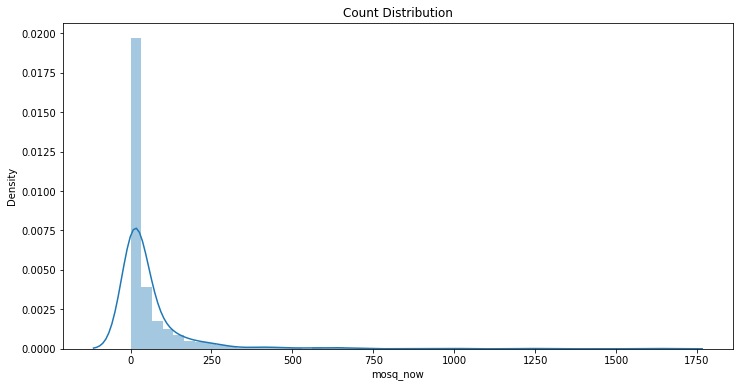

In [48]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_thessaly['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [49]:
mosq_quantilie = mosquito_data_thessaly['mosq_now'].quantile(0.95)

mosquito_data_thessaly['mosq_now'][mosquito_data_thessaly['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_27624/1191002822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_thessaly['mosq_now'][mosquito_data_thessaly['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


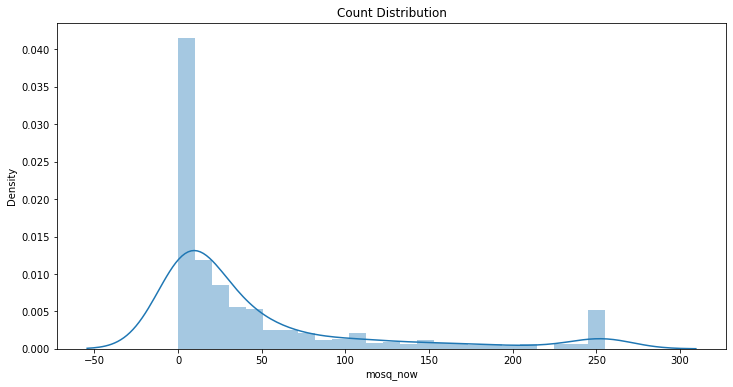

In [50]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_thessaly['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

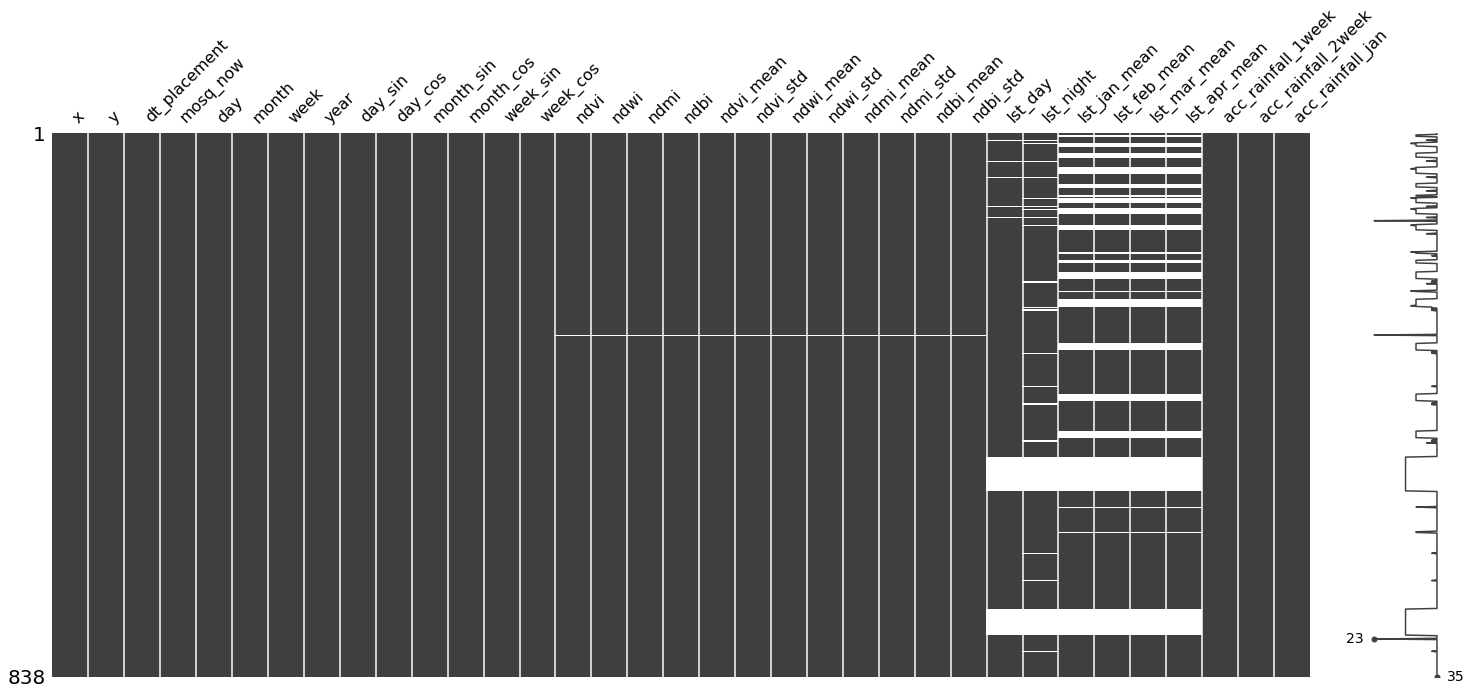

In [51]:
missingno.matrix(mosquito_data_thessaly)

In [52]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_thessaly[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [53]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_thessaly[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

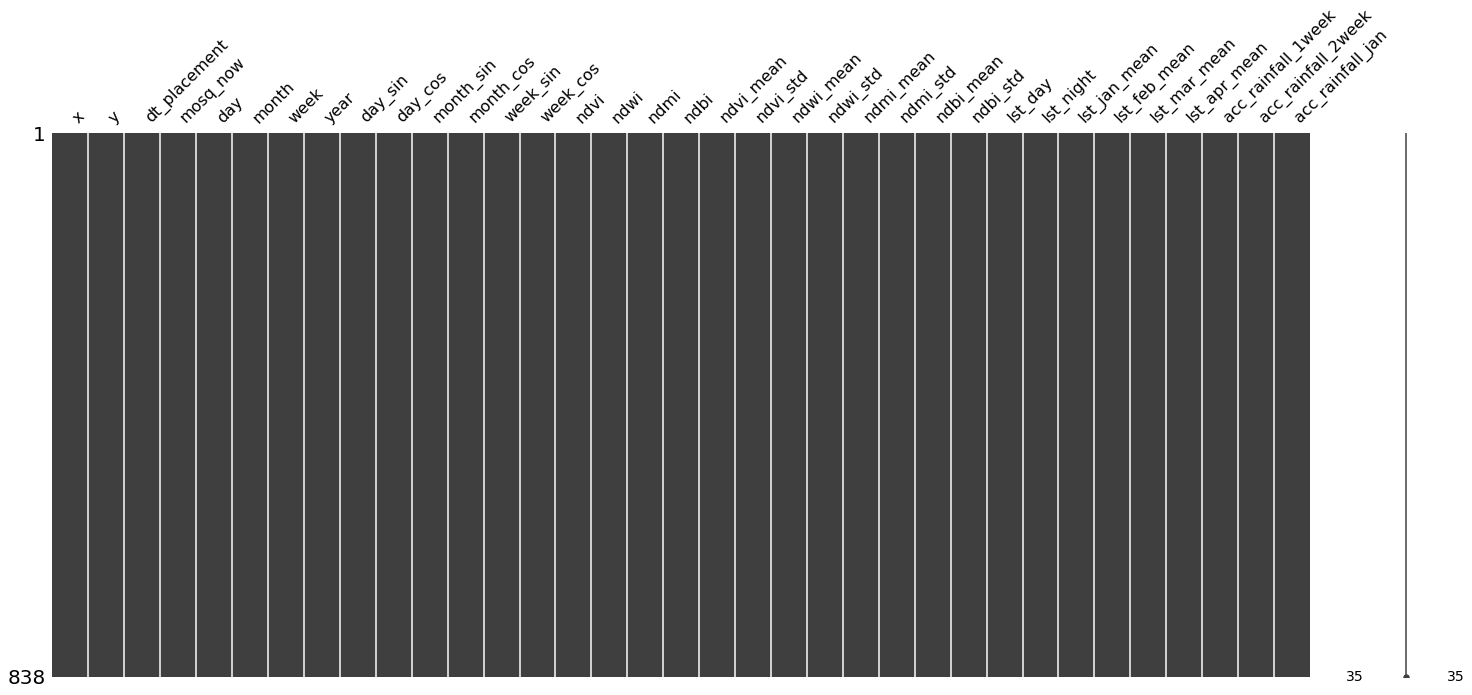

In [54]:
missingno.matrix(mosquito_data_thessaly)

In [55]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [56]:
mosquito_data_thessaly = initializer(mosquito_data_thessaly,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.    16.5  255.15]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [57]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_thessaly, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.27557 | Val Loss: 27.24908 | Train Acc: 4.122| Val Acc: 3.202
Epoch 002: | Train Loss: 37.14843 | Val Loss: 27.35600 | Train Acc: 3.619| Val Acc: 3.325
Epoch 003: | Train Loss: 35.55551 | Val Loss: 27.21889 | Train Acc: 3.298| Val Acc: 3.102
Epoch 004: | Train Loss: 33.66390 | Val Loss: 26.59583 | Train Acc: 2.908| Val Acc: 3.020
Epoch 005: | Train Loss: 33.43978 | Val Loss: 25.40918 | Train Acc: 2.863| Val Acc: 2.627
Epoch 006: | Train Loss: 33.22055 | Val Loss: 24.87247 | Train Acc: 2.717| Val Acc: 2.585
Epoch 007: | Train Loss: 32.95447 | Val Loss: 24.67826 | Train Acc: 2.729| Val Acc: 2.343
Epoch 008: | Train Loss: 32.90234 | Val Loss: 24.38603 | Train Acc: 2.748| Val Acc: 2.319
Epoch 009: | Train Loss: 32.65078 | Val Loss: 24.81353 | Train Acc: 2.688| Val Acc: 2.367
Epoch 010: | Train Loss: 32.50495 | Val Loss: 24.84182 | Train Acc: 2.592| Val Acc: 2.153
Epoch 011: | Train Loss: 32.21019 | Val Loss: 24.42221 | Train Acc: 2.553| Val Acc: 2.121
Epoch 012:

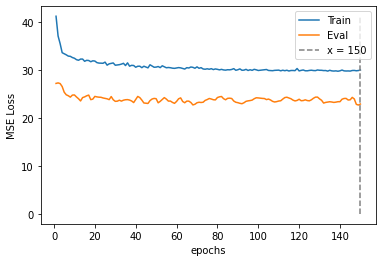

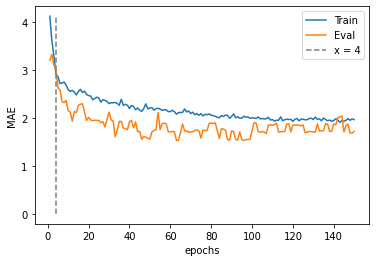

In [58]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [59]:
metrics(train, test, threshold=30)

MAE on train set:  31.102923864980664
min prediction: 1
max prediction: 191

MAE on test set:  30.62404608420113
Error ⩽ 30: 66.41 %
min prediction: 1
max prediction: 247


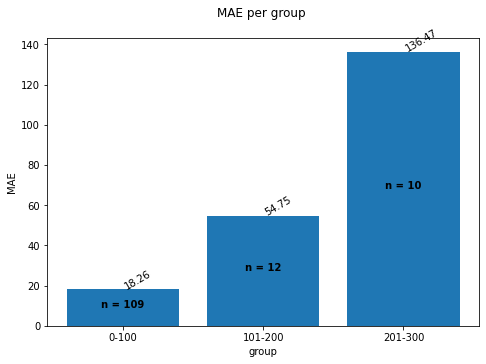

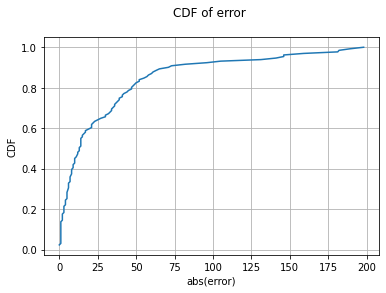

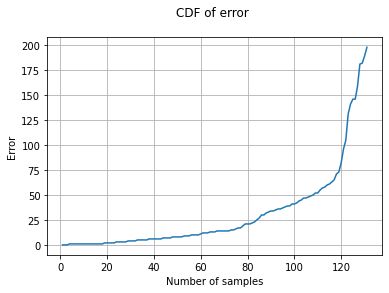

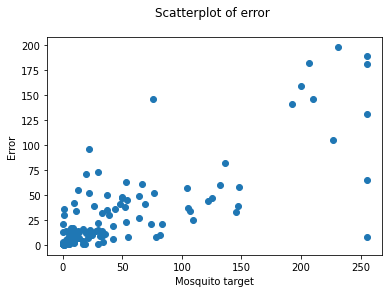

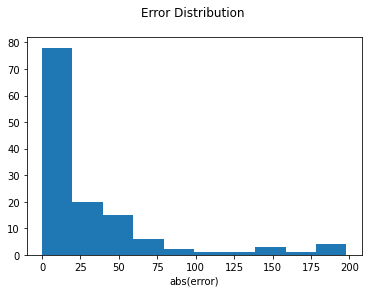

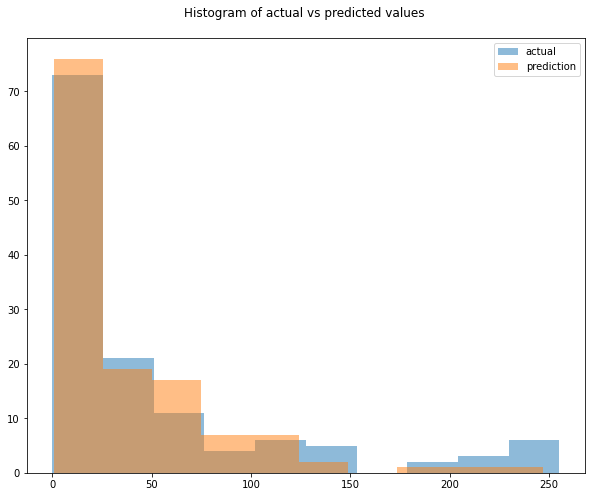

In [60]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.56345 | Val Loss: 0.03946 | Train Acc: 2.454| Val Acc: 0.542
Epoch 002: | Train Loss: 33.47510 | Val Loss: 0.08367 | Train Acc: 2.336| Val Acc: 0.542
Epoch 003: | Train Loss: 32.59369 | Val Loss: 0.11282 | Train Acc: 2.224| Val Acc: 0.542
Epoch 004: | Train Loss: 32.59403 | Val Loss: 1.10695 | Train Acc: 2.207| Val Acc: 1.542
Epoch 005: | Train Loss: 32.53977 | Val Loss: 1.26648 | Train Acc: 2.197| Val Acc: 1.542
Epoch 006: | Train Loss: 32.39026 | Val Loss: 0.32896 | Train Acc: 2.213| Val Acc: 0.542
Epoch 007: | Train Loss: 32.51052 | Val Loss: 0.00683 | Train Acc: 2.197| Val Acc: 0.542
Epoch 008: | Train Loss: 32.49480 | Val Loss: 0.24253 | Train Acc: 2.188| Val Acc: 0.542
Epoch 009: | Train Loss: 32.42637 | Val Loss: 0.22384 | Train Acc: 2.159| Val Acc: 0.542
Epoch 010: | Train Loss: 32.49405 | Val Loss: 0.59607 | Train Acc: 2.140| Val Acc: 0.542
Epoch 011: | Train Loss: 32.57770 | Val Loss: 0.29872 | Train Acc: 2.223| Val Acc: 0.542
Epoch 012: | Train Lo

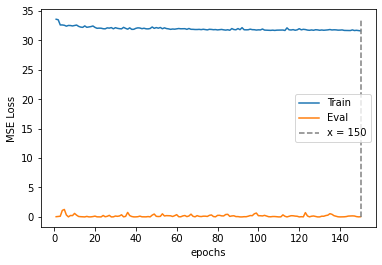

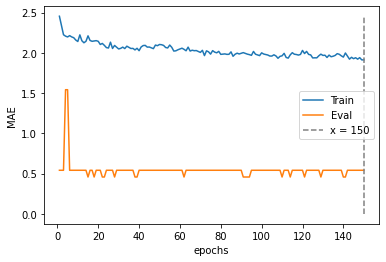

In [61]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_thessaly, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [62]:
# mamoth_columns = ['x','y','dt_placement','day','month','week','year', 
#                   'day_sin','day_cos','month_sin','month_cos','week_sin','week_cos',
#                   'ndvi','ndmi','ndwi','ndbi', 'ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean', 
#                   'ndvi_std','ndmi_std','ndwi_std','ndbi_std',
#                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean', 
#                   'acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_jan', 'mosq_now' ]

In [63]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [64]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [65]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [66]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [67]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [68]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

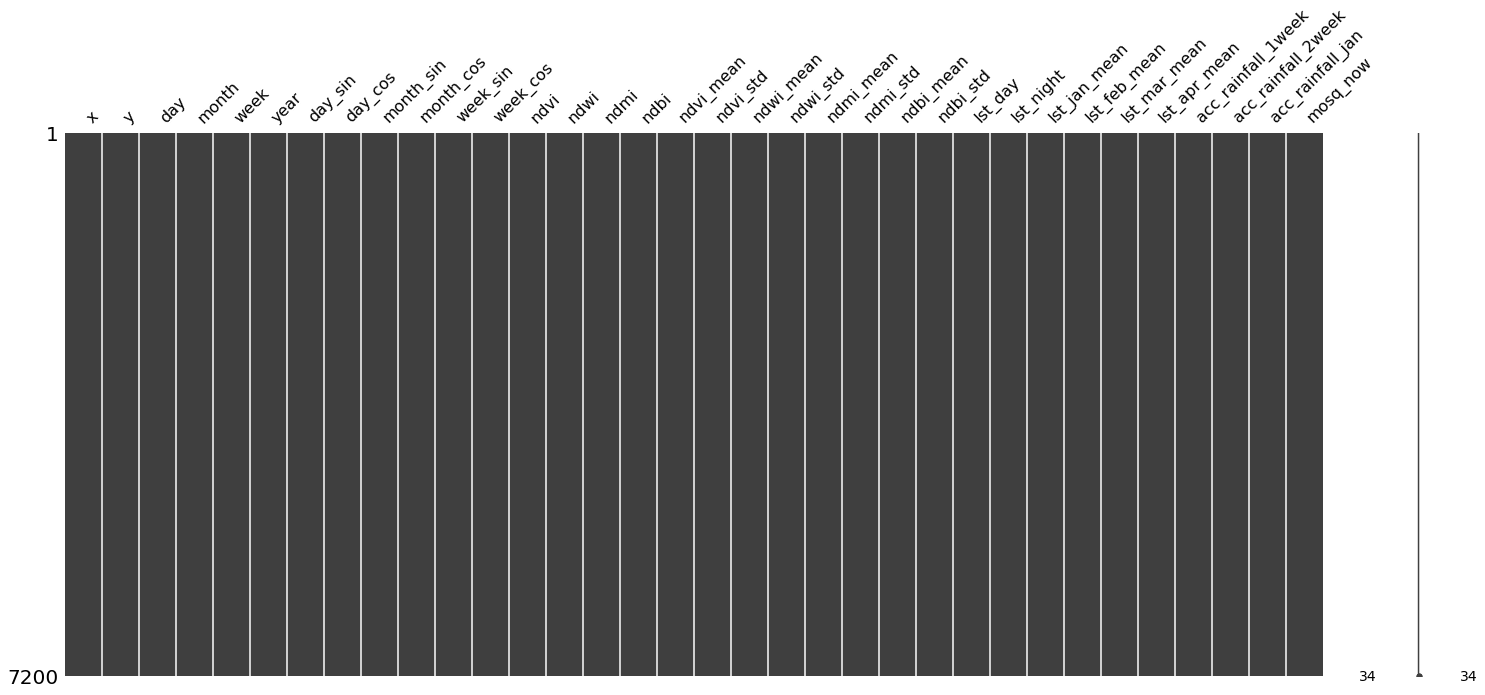

In [69]:
missingno.matrix(dataset_mamoth)

In [70]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [71]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [72]:
predictions = give_predictions(model, dataset_mamoth)

In [73]:
mosqutio_predictions['mosq_pred'] = predictions

In [74]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.77356,39.67760,2010-01-01,1
1,22.69493,39.10844,2010-01-01,1
2,23.91189,39.20320,2010-01-01,1
3,21.43052,39.25731,2010-01-01,1
4,22.93792,39.41186,2010-01-01,1
...,...,...,...,...
7195,22.53916,39.85570,2021-12-16,26
7196,21.81617,39.63146,2021-12-16,59
7197,22.29636,39.78805,2021-12-16,1
7198,22.05160,39.60973,2021-12-16,46


In [75]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x','y','dt_placement'])

In [76]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αγιας,θεσσαλιας,22.77356,39.67760,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14471.714286,14070.0,14219.612013,13922.623469,14136.897294,13878.458472,14496.295766,13962.024806,14633.668886,14065.292672,295.000000,295.000000,295.000000,295.000000,295.000000,22.057143,52.814286,0.000000,0,1,53,45.74874,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,661.8,17.3,10705.00,1
1,2010-01-01,αλμυρου,θεσσαλιας,22.69493,39.10844,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.222222,14253.0,14152.345459,13870.776279,14191.387279,13838.430904,14509.453398,13940.006808,14684.551160,14038.175999,260.444444,260.444444,260.444444,260.444444,260.444444,13.700000,31.211111,0.300000,0,1,53,45.21648,6,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,905.4,20.6,16004.00,1
2,2010-01-01,αλοννησου,θεσσαλιας,23.91189,39.20320,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14531.000000,14248.0,14291.857143,14136.142857,14248.230769,14025.000000,14403.076923,14089.200000,14549.130435,14178.875000,323.000000,323.000000,323.000000,323.000000,323.000000,62.200000,98.600000,0.000000,0,1,53,45.92025,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,129.6,21.2,3153.00,1
3,2010-01-01,αργιθεας,θεσσαλιας,21.43052,39.25731,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13579.222222,13686.888889,13946.166667,13586.089947,14322.111111,13797.862238,14594.027715,13969.056548,323.666667,323.666667,320.000000,320.000000,320.000000,47.133333,88.466667,22.100000,0,1,53,44.72587,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,372.9,9.3,3515.00,1
4,2010-01-01,βολου,θεσσαλιας,22.93792,39.41186,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14525.333333,NaN,14299.755952,13912.791667,14261.975758,13850.627350,14527.885470,13975.904412,14742.691667,14097.754579,252.666667,252.666667,252.666667,252.666667,252.666667,30.066667,48.733333,0.000000,0,1,53,45.60091,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,385.6,374.6,138865.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.53916,39.85570,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13908.747912,13643.002143,14205.595357,13867.065735,14298.427381,13761.768022,14603.587262,13897.571190,301.000000,301.000000,296.200000,296.200000,296.200000,0.000000,0.000000,788.880000,0,16,50,45.78745,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,576.7,23.8,11.99,26
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.81617,39.63146,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14155.953333,13736.146667,14361.958303,13873.382129,14577.722500,13796.656244,14873.710334,13993.580556,255.600000,255.600000,235.800000,235.800000,235.800000,0.000000,0.000000,819.310000,0,16,50,45.23934,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,607.6,133.9,78508.00,59
7197,2021-12-16,τυρναβου,θεσσαλιας,22.29636,39.78805,2021,12,0.388837,0.187181,-0.28902,-0.187181,0.440473,0.204898,-0.322835,-0.204898,0.056187,0.062905,0.077934,0.062905,NaN,NaN,14132.917582,13744.295202,14343.024483,13911.197325,14538.729365,13869.083791,14796.202381,14027.050919,294.750000,294.750000,294.750000,294.750000,294.750000,0.0000

<AxesSubplot:>

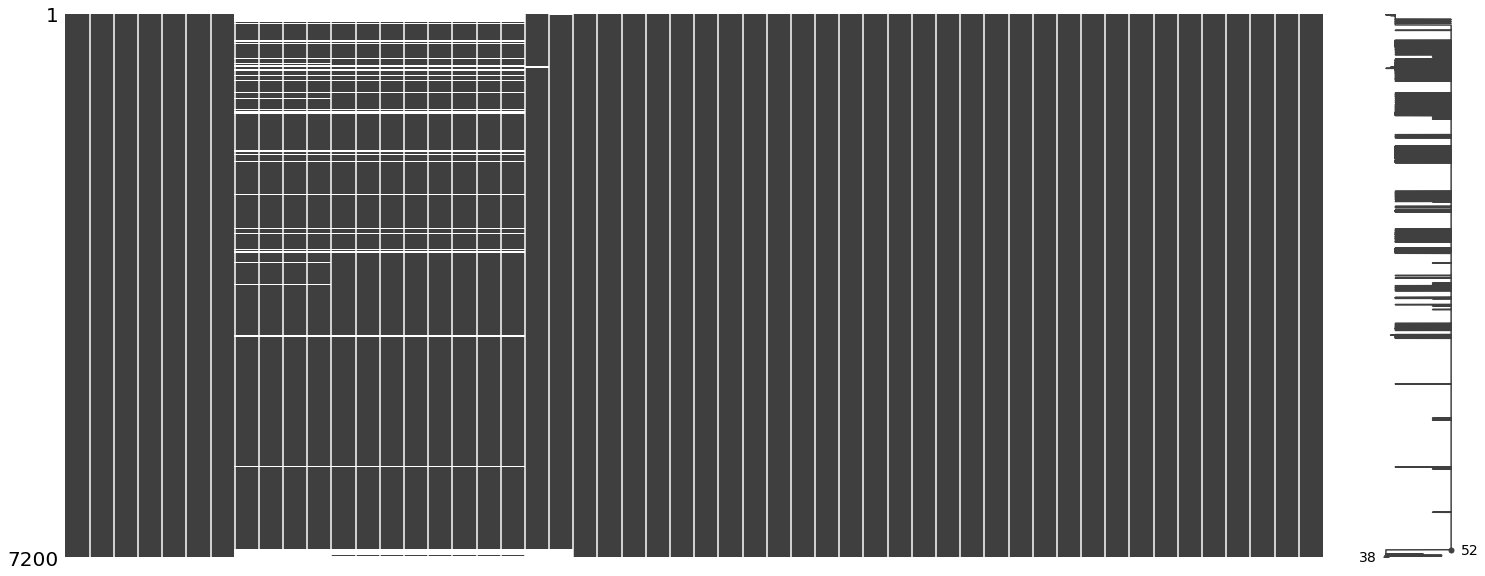

In [77]:
missingno.matrix(dataset)

In [78]:
dataset.reset_index(inplace=True, drop=True)

In [79]:
dataset = calculate_mosq_previous(dataset)

In [80]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

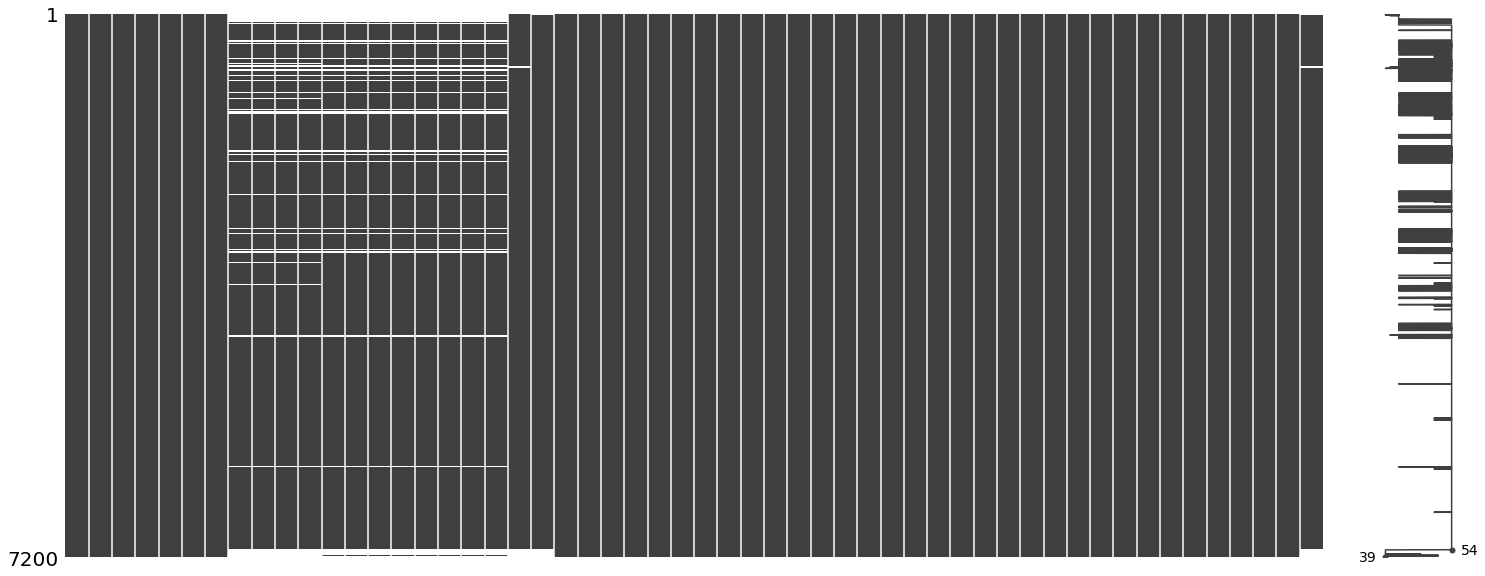

In [81]:
missingno.matrix(dataset)

In [82]:
dataset['case'].value_counts()

0    7127
1      47
2      20
3       5
7       1
Name: case, dtype: int64

In [83]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [84]:
dataset = convert_multiple_cases(dataset)

In [85]:
dataset['case'].value_counts()

0    7127
1     109
Name: case, dtype: int64

In [86]:
cols = dataset.columns

In [87]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'landcover_1990', 'landcover_2000', 'landcover_2006', 'landcover_2012', 
                 'landcover_2018', 'mosq_pred', 'mosq_previous', 'case']

In [88]:
dataset_thessaly = dataset[final_columns].copy()

In [89]:
dataset_thessaly

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,295.000000,295.000000,295.000000,295.000000,295.000000,1,0,0
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,260.444444,260.444444,260.444444,260.444444,260.444444,1,0,0
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,323.000000,323.000000,323.000000,323.000000,323.000000,1,0,0
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,323.666667,323.666667,320.000000,320.000000,320.000000,1,0,0
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,252.666667,252.666667,252.666667,252.666667,252.666667,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7231,22.28059,39.59376,2019-07-16,θεσσαλιας,λαρισαιων,13,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.43226,0.536262,0.156838,-0.504218,-0.156838,0.428365,0.032099,-0.429691,-0.032099,0.109346,0.110199,0.071032,0.110199,26.890000,33.020000,20.76,6.849091,-2.210227,15.461859,2.246667,23.459278,6.208366,24.715897,8.890000,0.000000,0.000000,239.5,211.500000,211.500000,211.500000,211.500000,211.500000,272,448,1
7232,22.28059,39.59376,2019-07-16,θεσσαλιας,λαρισαιων,13,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.43226,0.536262,0.156838,-0.504218,-0.156838,0.428365,0.032099,-0.429691,-0.032099,0.109346,0.110199,0.071032,0.110199,26.890000,33.020000,20.76,6.849091,-2.210227,15.461859,2.246667,23.459278,6.208366,24.715897,8.890000,0.000000,0.000000,239.5,211.500000,211.500000,211.500000,211.500000,211.500000,272,448,1
7233,22.28059,39.59376,2019-07-16,θεσσαλιας,λαρισαιων,13,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.43226,0.536262,0.156838,-0.504218,-0.156838,0.428365,0.032099,-0.429691,-0.032099,0.109346,0.110199,0.071032,0.110199,26.890000,33.020000,20.76,6.849091,-2.210227,15.461859,2.246667,23.459278,6.208366,24.715897,8.890000,0.000000,0.000000,239.5,21

In [90]:
dataset_thessaly.to_csv("data/GR_Thessaly_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)